In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
df_main = pd.read_csv("../data/raw_split/task1_merged.csv")

print("Task1 shape:", df_main.shape)


Task1 shape: (8548, 9)


In [3]:
df_main

,Topic,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Examiner_Comment
0,Bar Chart,(Bar chart) The graphs below show the total pe...,"Firstly, a research is done to show the total ...",NaN,NaN,NaN,NaN,4.5,**Task Achievement: [5]**\nThe response addres...
1,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar chart compares the proportion of films...,NaN,NaN,NaN,NaN,6.0,**Task Achievement: [7]**\nThe report provides...
2,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar charts depict the share of films relea...,NaN,NaN,NaN,NaN,9.0,**Task Achievement: [9]**\nThe report provides...
3,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar charts depicts the number of movies in...,NaN,NaN,NaN,NaN,5.0,**Task Achievement: [6]**\nThe report provides...
4,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar charts display the whole percentage of...,NaN,NaN,NaN,NaN,6.5,**Task Achievement: [7]**\nThe main features o...
...,...,...,...,...,...,...,...,...,...
8543,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The results of a survey conducted by a personn...,NaN,NaN,NaN,NaN,4.5,**Task Achievement: [5]**\nThe report provides...
8544,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The stipulated vertical bar chart depicts the ...,NaN,NaN,NaN,NaN,4.0,**Task Achievement: [4]**\nThe report does not...
8545,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The supplied bar graph compares different fact...,NaN,NaN,NaN,NaN,5.0,**Task Achievement: [6]**\nThe report addresse...
8546,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The supplied bar graph compares various factor...,NaN,NaN,NaN,NaN,8.0,**Task Achievement: [7]**\nThe report is well-...


In [4]:
df_main.duplicated(subset=["Essay"]).sum()

np.int64(0)

In [4]:
def extract_scores(text):

    if pd.isna(text) or not isinstance(text, str):
        return {}

    scores = {}

    # 1. NORMALIZE LOW SCORES

    def normalize_low_scores(match):
        return match.group(1)

    low_score_pattern = r"(?i)(?:below|under|less than|<)\s*(\d(?:\.[05])?)"
    text = re.sub(low_score_pattern, normalize_low_scores, text)

    clean_text = text.replace("__", "").replace("**", "")

    # 2. DEFINE SECTION HEADERS

    section_patterns = {
        "Task_Achievement": r"(?:Task Achievement|Task Response)",
        "Coherence_Cohesion": r"(?:Coherence and Cohesion|Coherence)",
        "Lexical_Resource": r"(?:Lexical Resource|Vocabulary)",
        "Range_Accuracy": r"(?:Grammatical Range and Accuracy|Grammar)",
        "Overall": r"(?:Overall Band Score|Overall)"
    }

    # 3. EXTRACT PER SECTION

    for key, pattern in section_patterns.items():

        # PLAN 0: SCORE IN HEADER
        # ## Task Achievement (7)

        header_pattern = rf"(?i)#+\s*{pattern}\s*[\(:]\s*(\d(?:\.[05])?)"
        m_header = re.search(header_pattern, clean_text)

        if m_header:
            scores[key] = float(m_header.group(1))
            continue

        # PLAN 0.5: Suggested Band Score
        # Suggested Band Score (Task Achievement): 7

        suggested_header = rf"Suggested\s+Band\s+Score\s*\(\s*{pattern}\s*\)\s*:\s*(\d(?:\.[05])?)"
        m_suggest_header = re.search(suggested_header, clean_text, re.I)

        if m_suggest_header:
            scores[key] = float(m_suggest_header.group(1))
            continue

        # Task Achievement: [7]
        # Task Achievement: 7

        header_inline = rf"(?i){pattern}\s*:\s*\[?(\d(?:\.[05])?)\]?"
        m_inline = re.search(header_inline, clean_text)

        if m_inline:
            scores[key] = float(m_inline.group(1))
            continue

        # PLAN 1: SPLIT SECTION CONTENT

        section_regex = rf"(?i)(?:#+\s*{pattern}.*?:?)(.*?)(?=\n#+\s*(?:Task Achievement|Task Response|Coherence and Cohesion|Coherence|Lexical Resource|Vocabulary|Grammatical Range and Accuracy|Grammar|Overall Band Score|Overall)|\Z)"

        m_section = re.search(section_regex, clean_text, re.S)

        if m_section:
            section_text = m_section.group(1)
        else:
            section_text = clean_text

        # PLAN 2: Explicit band mention

        pattern1 = r"(?:Band|Score|:|\(|\[)\s*(\d(?:\.[05])?)\b"
        m1 = re.search(pattern1, section_text, re.I)

        if m1:
            scores[key] = float(m1.group(1))
            continue

        # PLAN 3: Suggested band score

        pattern2 = r"suggested\s+(?:overall\s+)?band\s+score\s*(?:is|of|:)?\s*(\d(?:\.[05])?)"
        m2 = re.search(pattern2, section_text, re.I)

        if m2:
            scores[key] = float(m2.group(1))
            continue

        # PLAN 4: Narrative format

        pattern3 = r"received\s+(?:a\s+)?(\d(?:\.[05])?)\s+for"
        m3 = re.search(pattern3, section_text, re.I)

        if m3:
            scores[key] = float(m3.group(1))
            continue

        # PLAN 5: Fallback

        nums = re.findall(r"\b\d(?:\.[05])?\b", section_text)

        if nums:
            scores[key] = float(nums[-1])

    return scores

In [5]:
#Parse evaluation column 
parsed = df_main["Examiner_Comment"].apply(extract_scores)
parsed_df = pd.DataFrame(parsed.tolist())

parsed_df.head(1000)

,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall
0,5.0,4.0,4.0,4.0,4.5
1,7.0,5.5,5.5,5.5,6.0
2,9.0,9.0,8.5,9.0,9.0
3,6.0,4.5,4.5,4.5,5.0
4,7.0,5.5,6.5,6.5,6.5
...,...,...,...,...,...
995,6.0,4.0,4.0,4.0,4.5
996,7.0,8.0,7.0,6.0,7.0
997,7.0,8.0,6.5,9.0,7.5
998,7.0,6.0,6.5,5.5,6.5


In [6]:
parsed_df.tail(1000)

,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall
7548,5.5,4.5,5.5,4.5,5.0
7549,8.0,7.0,8.0,8.0,8.0
7550,7.5,6.5,6.5,7.5,7.0
7551,7.0,6.5,6.5,6.5,6.5
7552,6.0,5.0,5.0,5.0,5.5
...,...,...,...,...,...
8543,5.0,4.5,4.5,3.5,4.5
8544,4.0,3.0,5.0,3.0,4.0
8545,6.0,5.5,4.5,4.5,5.0
8546,7.0,8.0,7.0,9.0,8.0


In [7]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8548 entries, 0 to 8547
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Topic               8548 non-null   object 
 1   Question            8548 non-null   object 
 2   Essay               8548 non-null   object 
 3   Task_Response       0 non-null      float64
 4   Coherence_Cohesion  0 non-null      float64
 5   Lexical_Resource    0 non-null      float64
 6   Range_Accuracy      0 non-null      float64
 7   Overall             8548 non-null   float64
 8   Examiner_Comment    8063 non-null   object 
dtypes: float64(5), object(4)
memory usage: 601.2+ KB


In [8]:
overall_from_comment = parsed_df.get("Overall")
ground_truth_band = pd.to_numeric(df_main.get("Overall"), errors='coerce')

final_overall = overall_from_comment.fillna(ground_truth_band)

In [9]:
df_main_clean = pd.DataFrame({
    "Topic": df_main.get("Topic"),
    "Question": df_main.get("Question"),
    "Essay": df_main.get("Essay"),
    "Task_Achievement": parsed_df.get("Task_Achievement"),
    "Coherence_Cohesion": parsed_df.get("Coherence_Cohesion"),
    "Lexical_Resource": parsed_df.get("Lexical_Resource"),
    "Range_Accuracy": parsed_df.get("Range_Accuracy"),
    "Overall": final_overall,
    "Examiner_Comment": df_main.get("Examiner_Comment"),
})


In [10]:
df_main_clean

,Topic,Question,Essay,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Examiner_Comment
0,Bar Chart,(Bar chart) The graphs below show the total pe...,"Firstly, a research is done to show the total ...",5.0,4.0,4.0,4.0,4.5,**Task Achievement: [5]**\nThe response addres...
1,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar chart compares the proportion of films...,7.0,5.5,5.5,5.5,6.0,**Task Achievement: [7]**\nThe report provides...
2,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar charts depict the share of films relea...,9.0,9.0,8.5,9.0,9.0,**Task Achievement: [9]**\nThe report provides...
3,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar charts depicts the number of movies in...,6.0,4.5,4.5,4.5,5.0,**Task Achievement: [6]**\nThe report provides...
4,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar charts display the whole percentage of...,7.0,5.5,6.5,6.5,6.5,**Task Achievement: [7]**\nThe main features o...
...,...,...,...,...,...,...,...,...,...
8543,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The results of a survey conducted by a personn...,5.0,4.5,4.5,3.5,4.5,**Task Achievement: [5]**\nThe report provides...
8544,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The stipulated vertical bar chart depicts the ...,4.0,3.0,5.0,3.0,4.0,**Task Achievement: [4]**\nThe report does not...
8545,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The supplied bar graph compares different fact...,6.0,5.5,4.5,4.5,5.0,**Task Achievement: [6]**\nThe report addresse...
8546,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The supplied bar graph compares various factor...,7.0,8.0,7.0,9.0,8.0,**Task Achievement: [7]**\nThe report is well-...


In [11]:
criteria_cols = [
    "Task_Achievement",
    "Coherence_Cohesion",
    "Lexical_Resource",
    "Range_Accuracy"
]

print("Missing criteria:")
print(df_main_clean[criteria_cols].isna().sum())

print("\nOverall missing:")
print(df_main_clean["Overall"].isna().sum())

Missing criteria:
Task_Achievement      485
Coherence_Cohesion    485
Lexical_Resource      485
Range_Accuracy        485
dtype: int64

Overall missing:
0


In [12]:
missing_rows = df_main_clean[
    df_main_clean[criteria_cols].isnull().any(axis=1)
]

print("Total missing rows:", len(missing_rows))

for i in range(10):
    print("\n ")
    print(missing_rows["Examiner_Comment"].iloc[i])


fail = df_main_clean[
    df_main_clean[criteria_cols].isna().any(axis=1)
]

print(fail.iloc[0]["Examiner_Comment"])

Total missing rows: 485

 
nan

 
nan

 
nan

 
nan

 
nan

 
nan

 
nan

 
nan

 
nan

 
nan
nan


In [13]:
def round_band(x):
    if pd.isna(x):
        return np.nan

    integer = int(x)
    decimal = x - integer

    if decimal < 0.25:
        return integer
    elif decimal <= 0.5:
        return integer + 0.5
    elif decimal < 0.75:
        return integer + 0.5
    else:
        return integer + 1

In [14]:
df_main_clean["Overall_Clean"] = df_main_clean[
    [
        "Task_Achievement",
        "Coherence_Cohesion",
        "Lexical_Resource",
        "Range_Accuracy"
    ]
].mean(axis=1).apply(round_band)

In [ ]:
df_main_clean["length"] = df_main_clean["Essay"].fillna("").apply(lambda x: len(x.split()))

In [16]:
df_main_clean = df_main_clean[
    [
        "Topic",
        "Question",
        "Essay",
        "Task_Achievement",
        "Coherence_Cohesion",
        "Lexical_Resource",
        "Range_Accuracy",
        "Overall",
        "Overall_Clean",
        "Examiner_Comment",
        "length"
    ]
]

In [17]:
df_main_clean.sort_index(inplace=False)

,Topic,Question,Essay,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length
0,Bar Chart,(Bar chart) The graphs below show the total pe...,"Firstly, a research is done to show the total ...",5.0,4.0,4.0,4.0,4.5,4.5,**Task Achievement: [5]**\nThe response addres...,178
1,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar chart compares the proportion of films...,7.0,5.5,5.5,5.5,6.0,6.0,**Task Achievement: [7]**\nThe report provides...,187
2,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar charts depict the share of films relea...,9.0,9.0,8.5,9.0,9.0,9.0,**Task Achievement: [9]**\nThe report provides...,155
3,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar charts depicts the number of movies in...,6.0,4.5,4.5,4.5,5.0,5.0,**Task Achievement: [6]**\nThe report provides...,191
4,Bar Chart,(Bar chart) The graphs below show the total pe...,The bar charts display the whole percentage of...,7.0,5.5,6.5,6.5,6.5,6.5,**Task Achievement: [7]**\nThe main features o...,198
...,...,...,...,...,...,...,...,...,...,...,...
8543,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The results of a survey conducted by a personn...,5.0,4.5,4.5,3.5,4.5,4.5,**Task Achievement: [5]**\nThe report provides...,151
8544,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The stipulated vertical bar chart depicts the ...,4.0,3.0,5.0,3.0,4.0,4.0,**Task Achievement: [4]**\nThe report does not...,194
8545,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The supplied bar graph compares different fact...,6.0,5.5,4.5,4.5,5.0,5.0,**Task Achievement: [6]**\nThe report addresse...,248
8546,Bar Chart,"those aged from 18-30 and those aged 45-60, an...",The supplied bar graph compares various factor...,7.0,8.0,7.0,9.0,8.0,8.0,**Task Achievement: [7]**\nThe report is well-...,249


In [18]:
df_main_clean = df_main_clean.sort_values(
    by=criteria_cols,
    ascending=True,
    na_position="first"
)

In [19]:
df_main_clean

,Topic,Question,Essay,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length
79,Process Diagram,"Eating sweet foods produces acid in the mouth,...",The diagram illustrates a comparsion of differ...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,249
80,Process Diagram,"Eating sweet foods produces acid in the mouth,...",The diagram illustrates the acid level in the ...,NaN,NaN,NaN,NaN,7.0,NaN,NaN,254
81,Line Graph,"Eating sweet foods produces acid in the mouth,...",The line graph depicts how a decay can appear ...,NaN,NaN,NaN,NaN,5.5,NaN,NaN,176
110,Table,Percentage of UK people who consumed daily rec...,The bar chart illustrates the rate of people w...,NaN,NaN,NaN,NaN,5.5,NaN,NaN,223
111,Table,Percentage of UK people who consumed daily rec...,The bar chart shed light on the proportions of...,NaN,NaN,NaN,NaN,7.5,NaN,NaN,213
...,...,...,...,...,...,...,...,...,...,...,...
8468,Map,the plans below show the layout of a universit...,The two maps illustrate the changes that will ...,9.0,9.0,9.0,9.0,9.0,9.0,**Task Achievement: [9]**\nThe report provides...,255
8498,Table,the table below gives information on consumer ...,The table provides information about the amoun...,9.0,9.0,9.0,9.0,9.0,9.0,**Task Achievement: [9]**\nThe report provides...,174
8516,Table,the table below presents the food consumption ...,The table illustrates the weekly consumption o...,9.0,9.0,9.0,9.0,9.0,9.0,**Task Achievement: [9]**\nThe report fully ad...,178
8517,Table,the table below presents the food consumption ...,The table illustrates the weekly food consumpt...,9.0,9.0,9.0,9.0,9.0,9.0,**Task Achievement: [9]**\nThe report fully ad...,199


In [20]:
#Save
df_main_clean.to_csv("../data/processing/task1_ielts_dataset.csv", index=False)

print("file saved as task1_ielts_dataset.csv")

file saved as task1_ielts_dataset.csv


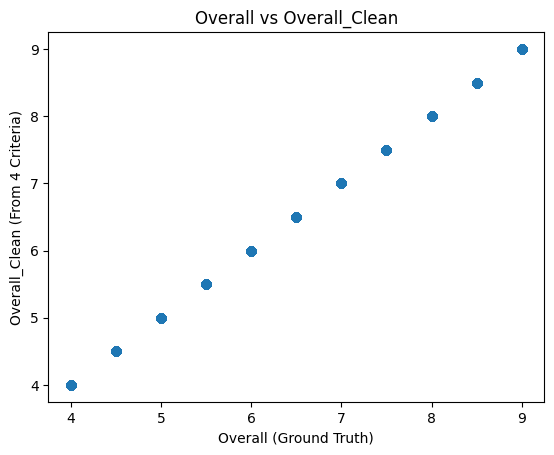

In [21]:
import matplotlib.pyplot as plt

x = df_main_clean["Overall"]
y = df_main_clean["Overall_Clean"]

plt.figure()

plt.scatter(x, y)

plt.xlabel("Overall (Ground Truth)")
plt.ylabel("Overall_Clean (From 4 Criteria)")
plt.title("Overall vs Overall_Clean")

plt.show()